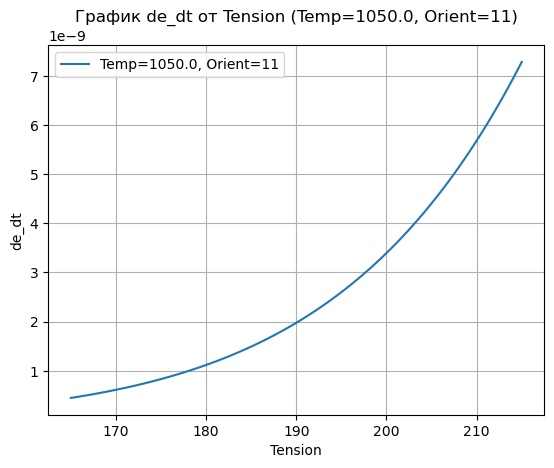

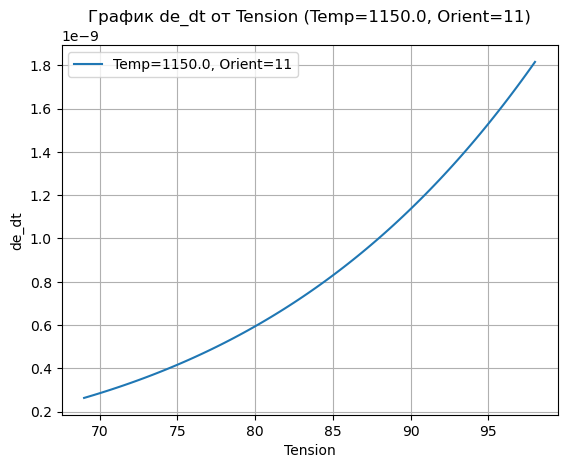

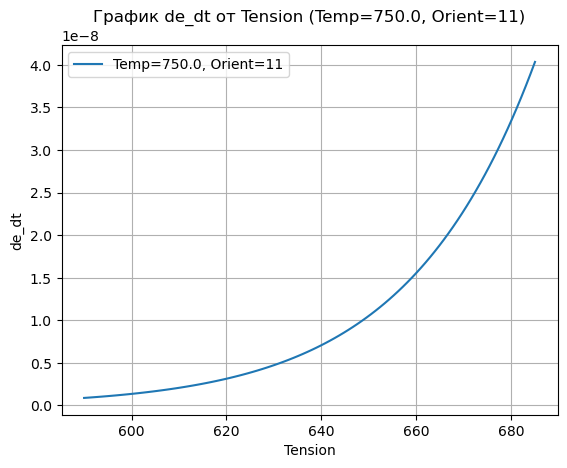

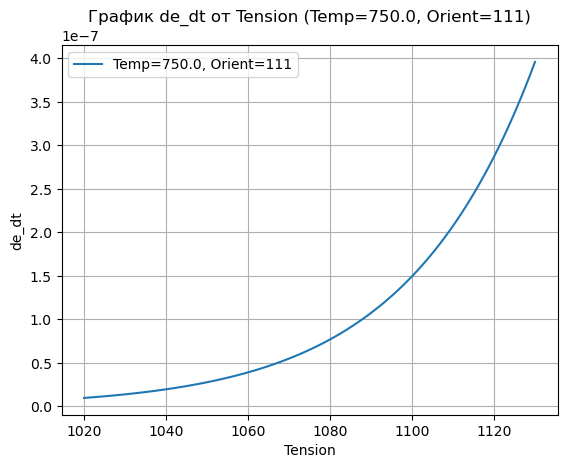

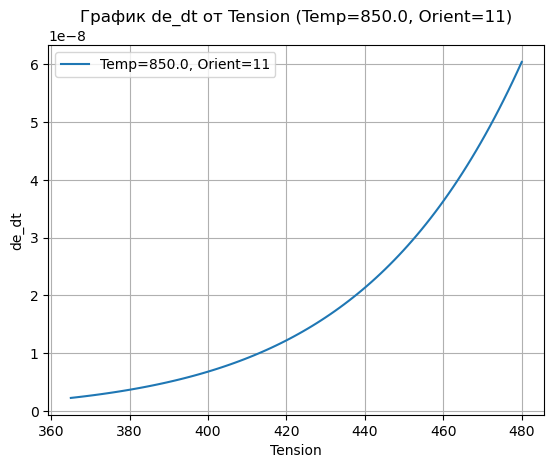

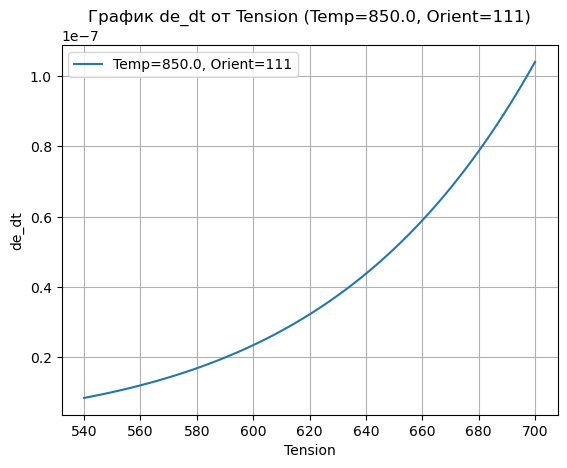

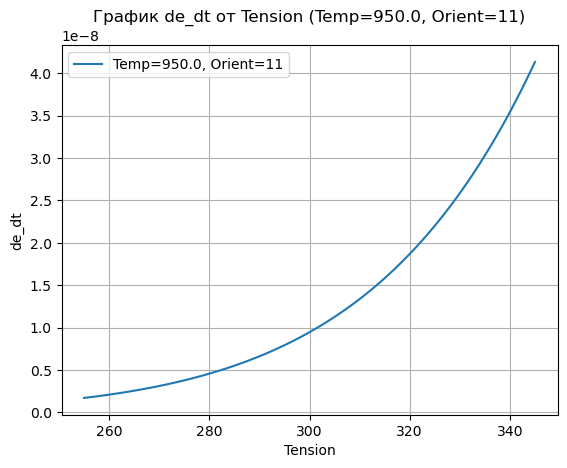

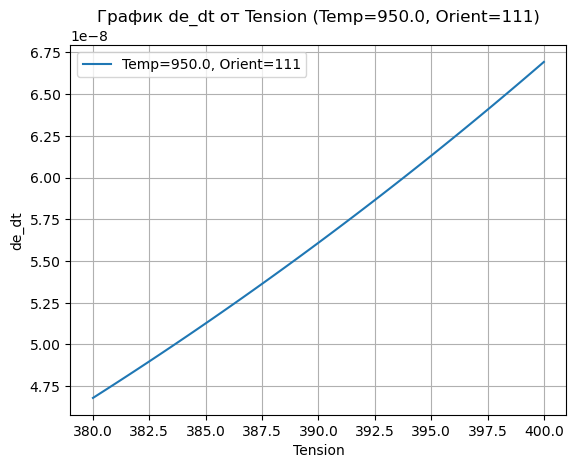

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from db_utils import load_config, create_psycopg2_connection


def plot_de_dt_by_material(config_path: str):
    """
    Строит графики de_dt от Tension для каждой таблицы temp_{temp}_orient_{orient},
    используя константы A и n из таблицы constants_table.
    Значения Tension генерируются в диапазоне min-max для каждой таблицы.
    """
    config = load_config(config_path)
    conn, cur = create_psycopg2_connection(config)

    try:
        # Получаем список таблиц с данными
        cur.execute("""
            SELECT table_name
            FROM information_schema.tables
            WHERE table_schema = 'public' AND table_name LIKE 'temp_%_orient_%';
        """)
        tables = cur.fetchall()

        if not tables:
            print("Нет таблиц с данными для построения графиков.")
            return

        # Получаем константы A и n из таблицы constants_table
        cur.execute("""
            SELECT "Orient", "Temp", "A", "n"
            FROM constants_table;
        """)
        constants_data = cur.fetchall()

        if not constants_data:
            print("Таблица constants_table пуста. Сначала найдите константы A и n.")
            return

        # Создаем словарь для хранения констант
        constants_dict = {(row[0], row[1]): (row[2], row[3]) for row in constants_data}

        # Обрабатываем каждую таблицу
        for table in tables:
            table_name = table[0]

            # Извлекаем температуру и ориентацию из имени таблицы
            parts = table_name.split('_')
            temp = float(parts[1])  # Температура
            orient = parts[3]       # Ориентация

            # Получаем константы A и n для данной температуры и ориентации
            if (orient, temp) not in constants_dict:
                print(f"Нет констант для Temp={temp}, Orient={orient}.")
                continue

            A, n = constants_dict[(orient, temp)]

            # Получаем данные из таблицы
            cur.execute(f"""
                SELECT "Tension"
                FROM {table_name};
            """)
            tensions = [row[0] for row in cur.fetchall()]

            if not tensions:
                print(f"Таблица {table_name} пуста.")
                continue

            # Находим минимальное и максимальное Tension для этой таблицы
            min_tension = min(tensions)
            max_tension = max(tensions)

            # Генерируем значения Tension в диапазоне [min_tension, max_tension]
            tension_values = np.linspace(min_tension, max_tension, 100)

            # Рассчитываем de_dt по формуле de_dt = A * Tension^n
            de_dt_values = A * np.power(tension_values, n)

            # Строим график
            plt.figure()
            plt.plot(tension_values, de_dt_values, label=f"Temp={temp}, Orient={orient}")
            plt.xlabel("Tension")
            plt.ylabel("de_dt")
            plt.title(f"График de_dt от Tension (Temp={temp}, Orient={orient})")
            plt.legend()
            plt.grid(True)
            plt.show()

    except Exception as e:
        print(f"Ошибка при выполнении операций с базой данных: {e}")
    finally:
        # Закрываем курсор и соединение
        cur.close()
        conn.close()


if __name__ == "__main__":
    config_path = 'config_to_connection.json'
    plot_de_dt_by_material(config_path)